# Detección de Depresión Mayor con fMRI e IA
## Introducción al Proyecto

**Samsung Innovation Campus — Predicción de Depresión**

Este notebook presenta el contexto clínico, los datasets utilizados, el pipeline completo de procesamiento y las decisiones de diseño del proyecto.

---

## Índice
1. [Contexto clínico](#1)
2. [Dataset REST-meta-MDD](#2)
3. [Features: FC y ALFF](#3)
4. [Problema multi-sitio y ComBat](#4)
5. [Pipeline de preprocesamiento](#5)
6. [Experimentos de features](#6)
7. [Dataset PHQ-9](#7)
8. [Limitaciones del proyecto](#8)

## 1. Contexto clínico <a id='1'></a>

El **Trastorno Depresivo Mayor (MDD)** es una de las enfermedades mentales más importantes del mundo, afectando a más de 280 millones de personas según la OMS. Se caracteriza por episodios persistentes de estado de ánimo deprimido, anhedonia (pérdida de placer), fatiga, alteraciones del sueño y pensamientos suicidas.

### ¿Por qué neuroimagen?

El diagnóstico actual de MDD es subjetivo, se basa en entrevistas clínicas y cuestionarios. No existe un biomarcador biológico validado. Esto genera:
- Alta variabilidad entre evaluadores
- Diagnóstico tardío
- Dificultad para distinguir subtipos de depresión

La **fMRI en reposo (rs-fMRI)** permite medir la actividad cerebral sin que el sujeto realice ninguna tarea. Estudios han demostrado que pacientes con MDD presentan alteraciones en la conectividad funcional entre regiones cerebrales — especialmente en la red de modo por defecto (DMN) y las conexiones frontolímbicas.

### Objetivo del proyecto

Desarrollar un clasificador automático MDD vs HC (controles sanos) usando features de fMRI, con el fin de explorar la viabilidad de un biomarcador objetivo basado en neuroimagen.

## 2. Dataset REST-meta-MDD <a id='2'></a>

**REST-meta-MDD Phase 1** es el mayor dataset público de rs-fMRI para depresión, compilado por el consorcio REST-meta-MDD a partir de 25 hospitales en China.

In [5]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('..'))
plt.rcParams['figure.dpi'] = 120

# Cargar metadata y labels del pipeline
df_meta = pd.read_excel('../data/raw/REST-meta-MDD-PhenotypicData_WithHAMDSubItem_V4.xlsx')
df_meta['site'] = df_meta['ID'].str.extract(r'^(S\d+)')

labels = np.load('../data/processed/labels.npy')

print('Estadisticas Generales')
print(f'Total sujetos             : {len(labels)}')
print(f'MDD                       : {labels.sum()} ({labels.mean()*100:.1f}%)')
print(f'HC                        : {(labels==0).sum()} ({(1-labels.mean())*100:.1f}%)')
print()
print(f'Sujetos en metadata       : {len(df_meta)}')
print(f'Edad media                : {df_meta["Age"].mean():.1f} ± {df_meta["Age"].std():.1f} años')
print(f'Sexo (1=M, 2=F)           : {df_meta["Sex"].value_counts().to_dict()}')
print(f'Sitios                    : {df_meta["site"].nunique()}')

Estadisticas Generales
Total sujetos             : 2293
MDD                       : 1225 (53.4%)
HC                        : 1068 (46.6%)

Sujetos en metadata       : 1276
Edad media                : 36.2 ± 14.6 años
Sexo (1=M, 2=F)           : {2: 813, 1: 463}
Sitios                    : 24


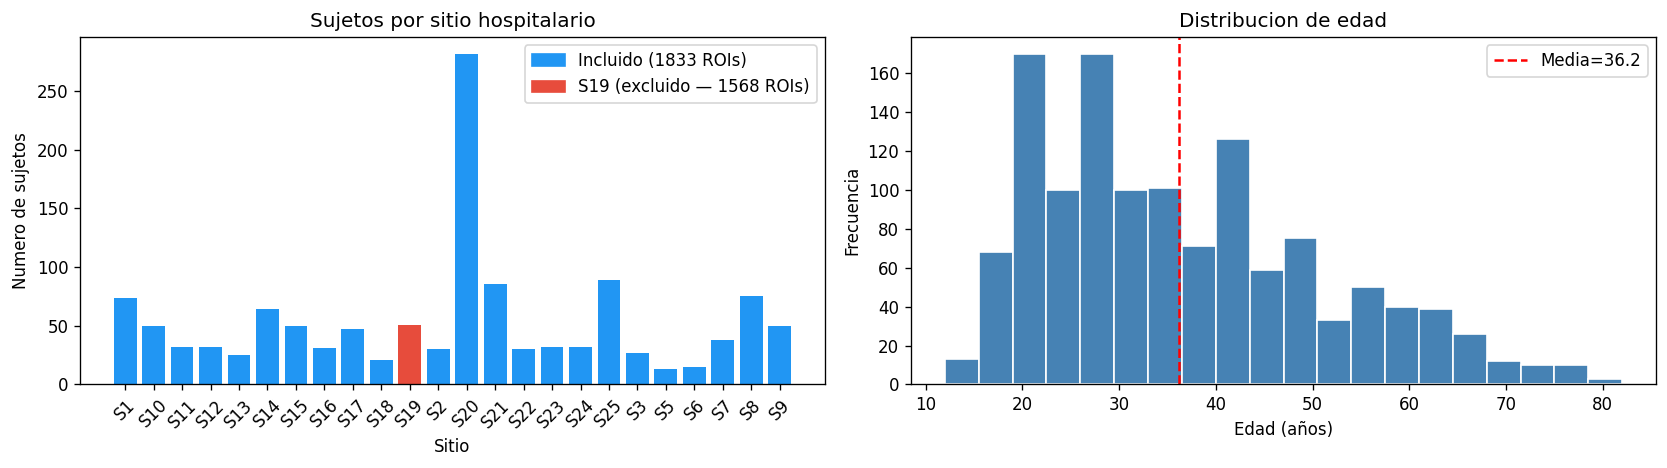

In [6]:
# Distribucion de sujetos por sitio
sujetos_por_sitio = df_meta.groupby('site').size().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Barplot por sitio
colores = ['#e74c3c' if s == 'S19' else '#2196F3' for s in sujetos_por_sitio.index]
ax1.bar(sujetos_por_sitio.index, sujetos_por_sitio.values, color=colores)
ax1.set_xlabel('Sitio')
ax1.set_ylabel('Numero de sujetos')
ax1.set_title('Sujetos por sitio hospitalario')
ax1.tick_params(axis='x', rotation=45)
excluido = mpatches.Patch(color='#e74c3c', label='S19 (excluido — 1568 ROIs)')
incluido = mpatches.Patch(color='#2196F3', label='Incluido (1833 ROIs)')
ax1.legend(handles=[incluido, excluido])

# Distribucion de edad
ax2.hist(df_meta['Age'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax2.set_xlabel('Edad (años)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribucion de edad')
ax2.axvline(df_meta['Age'].mean(), color='red', linestyle='--', label=f'Media={df_meta["Age"].mean():.1f}')
ax2.legend()

plt.tight_layout()
plt.show()

### Exclusión del sitio S19

El sitio S19 utiliza un atlas con **1,568 ROIs** en lugar de las 1,833 esperadas por el atlas AAL estándar. Incluirlo generaría matrices de conectividad de dimensión incompatible. Se excluye del pipeline, quedando **2,293 sujetos** de 24 sitios.

### Split del dataset

Se usa un split estratificado 70/15/15, misma proporción MDD/HC en cada conjunto.
| Conjunto | Sujetos | MDD | HC |
|---|---|---|---|
| Train | 1,605 | 857 | 748 |
| Val | 344 | 184 | 160 |
| Test | 344 | 184 | 160 |

## 3. Features: FC y ALFF <a id='3'></a>

### ¿Qué mide la fMRI en reposo?

La **fMRI (Resonancia Magnética Funcional)** mide indirectamente la actividad neuronal a través de la señal **BOLD**
(*Blood Oxygen Level Dependent*). Cuando una región cerebral se activa, consume más oxígeno y el flujo sanguíneo local
aumenta, esto genera un cambio en la señal magnética detectable por el escáner.

En la fMRI en **reposo** (*resting-state*), el sujeto no realiza ninguna tarea, simplemente permanece quieto con los
ojos cerrados. Aun así, el cerebro mantiene actividad espontánea organizada en redes funcionales. Esta actividad enreposo es reproducible entre sujetos y se altera en enfermedades mentales como la depresión.

---
### Conectividad Funcional (FC)

La FC mide la **correlación temporal** entre las señales BOLD de pares de regiones cerebrales (ROIs) a lo largo del
tiempo. Si dos regiones tienen señales que suben y bajan de forma sincronizada, se dice que están **funcionalmente
conectadas**.

Con **1,833 ROIs** del atlas AAL (*Automated Anatomical Labeling*), se obtiene una matriz de correlación de 1,833 ×
1,833. Se extrae únicamente el triángulo superior para evitar redundancia:

$$n_{\text{features FC}} = \frac{1833 \times 1832}{2} = 1{,}679{,}028 \text{ features por sujeto}$$

En pacientes con MDD se han reportado alteraciones en la conectividad de la **Red de Modo por Defecto (DMN)** y en las conexiones entre el **córtex prefrontal** y el **sistema límbico** (emocional).

> **Problema computacional:** con 2,293 sujetos, la matriz FC completa ocupa ~44 GB. Se utiliza **IncrementalPCA**
para reducir dimensionalidad procesando los datos en batches sin saturar la RAM.

---

### ALFF (Amplitude of Low-Frequency Fluctuations)

ALFF mide la **amplitud de las fluctuaciones espontáneas de baja frecuencia** (0.01–0.08 Hz) en la señal BOLD. Estas
oscilaciones lentas reflejan la actividad neuronal de cada región cuanto mayor es el ALFF, más "activa"
está esa zona en reposo.

Se calcula región por región usando el atlas **Harvard-Oxford**, resultando en **49 features** por sujeto. Estudios
han encontrado ALFF reducido en el **córtex prefrontal** y el **hipocampo** en pacientes con MDD, consistente con la
hipofrontalidad y las alteraciones de memoria asociadas a la depresión.

---
### ¿Por qué combinar FC y ALFF?

FC y ALFF capturan aspectos **complementarios** de la función cerebral:

| Feature | Mide | Escala | Dimensión |
|---|---|---|---|
| FC | Sincronización *entre* regiones | Global (red) | 1,679,028 |
| ALFF | Actividad *local* de cada región | Local (nodo) | 49 |
| Combined | Ambas | Global + Local | 249 (con PCA) |

La hipótesis es que combinarlas aporta información no redundante: un paciente puede tener conectividad alterada sin
que su actividad local cambie significativamente, o viceversa. Los resultados experimentales confirman esto
**combined** supera consistentemente a **fc** y **alff** por separado.


## 4. Problema multi-sitio y ComBat <a id='4'></a>

### Problematica

Con 24 sitios hospitalarios usando diferentes escáneres, protocolos y parámetros de adquisición, los datos podrian tener **efectos de sitio**: variaciones sistemáticas no relacionadas con la biología del paciente sino con el equipo de medición. Sin corregir, un modelo puede aprender a distinguir sitios en lugar de MDD vs HC.

### ComBat

**ComBat** es un algoritmo de armonización desarrollado originalmente para datos de microarrays genómicos y adaptado a neuroimagen.

Se aplica como paso opcional: el pipeline genera experimentos **con y sin ComBat** para cuantificar su impacto.

## 5. Pipeline de preprocesamiento <a id='5'></a>

### Diagrama del pipeline completo

| Etapa | Script | Entrada | Salida |
|---|---|---|---|
| Carga de datos | `data_loader.py` | Archivos `.mat` y NIfTI | Metadata + señales ROI |
| Extracción de features | `feature_extraction.py` | Señales ROI | `fc_features.npy` (2293×1,679,028), `alff_features.npy` (2293×49) |
| Armonización (opcional) | `combat.py` | Features + info de sitio | `fc_features_combat.npy`, `alff_features_combat.npy` |
| Preprocesamiento | `preprocessing.py` | Features | `X_train/val/test_{experimento}.npy` (14 experimentos) |
| Entrenamiento clásico | `train_svm/rf/xgboost.py` | Splits preprocesados | Métricas JSON + modelos `.pkl` |
| Deep Learning (MLP) | `train_mlp.py` | Splits preprocesados | Métricas JSON + modelo `.keras` |
| Regresión PHQ-9 | `regression.py` | Dataset PHQ-9 | Métricas JSON |
| Clustering PHQ-9 | `clustering.py` | Dataset PHQ-9 | Figuras + resumen JSON |

### Decisiones clave de diseño

**IncrementalPCA en lugar de PCA estándar**

La matriz FC completa ocupa ~44 GB no cabe en mi RAM. IncrementalPCA procesa los datos en batches, ajustando la descomposición SVD iterativamente sin cargar todo a la vez:

```
Batch size: 300 sujetos × 1,679,028 features × 8 bytes = 3.8 GB por batch
```

**StandardScaler fit solo en train**

El scaler se ajusta *únicamente* con datos de entrenamiento y se aplica a val y test. Si se ajustara con todos los datos, los estadísticos (media, desviación) del test contaminarían el modelo.

**Problema de overfitting detectado y corregido**

Durante el desarrollo, ANOVA y MRMR con K=2000 features causaba overfitting severo (train AUC=1.0, test AUC≈0.55) porque **features > muestras**. Con 1,605 muestras de train y 2,000 features, el modelo tiene más parámetros que ejemplos. Se redujo a K=500.

## 6. Experimentos de features <a id='6'></a>

Se definen 7 experimentos base, cada uno con una estrategia distinta de representación. Todos se corren con y sin ComBat (14 experimentos en total por modelo).

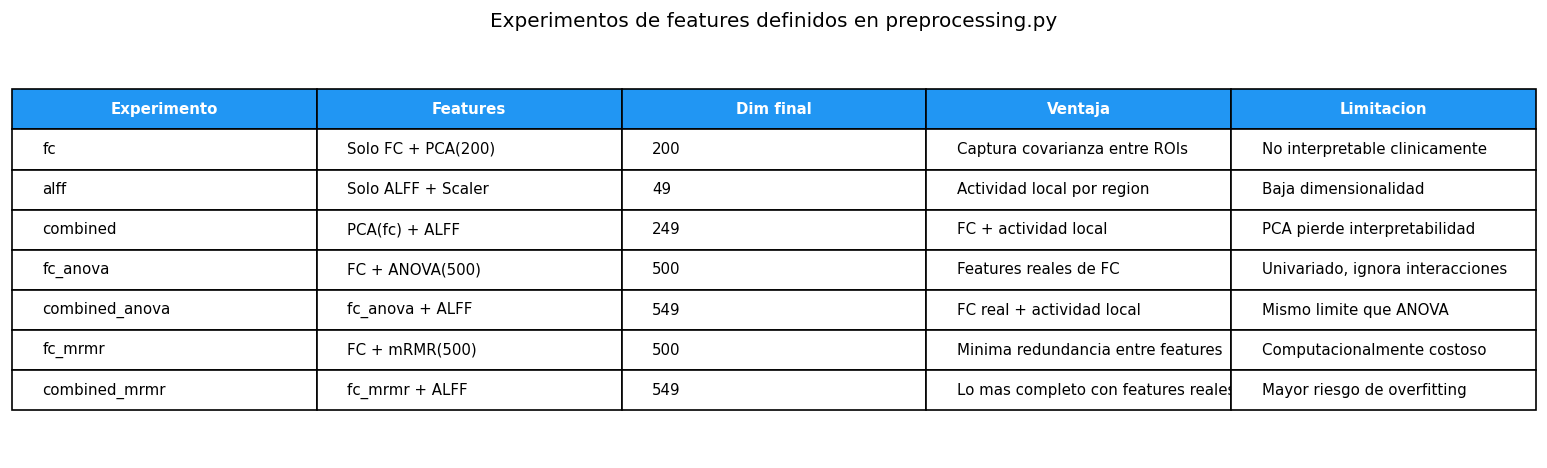

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

tabla = [
    ['Experimento', 'Features', 'Dim final', 'Ventaja', 'Limitacion'],
    ['fc',            'Solo FC + PCA(200)',         '200', 'Captura covarianza entre ROIs', 'No interpretable clinicamente'],
    ['alff',          'Solo ALFF + Scaler',          '49',  'Actividad local por region',    'Baja dimensionalidad'],
    ['combined',      'PCA(fc) + ALFF',             '249', 'FC + actividad local',           'PCA pierde interpretabilidad'],
    ['fc_anova',      'FC + ANOVA(500)',             '500', 'Features reales de FC',          'Univariado, ignora interacciones'],
    ['combined_anova','fc_anova + ALFF',             '549', 'FC real + actividad local',      'Mismo limite que ANOVA'],
    ['fc_mrmr',       'FC + mRMR(500)',              '500', 'Minima redundancia entre features','Computacionalmente costoso'],
    ['combined_mrmr', 'fc_mrmr + ALFF',             '549', 'Lo mas completo con features reales','Mayor riesgo de overfitting'],
]

t = ax.table(cellText=tabla[1:], colLabels=tabla[0], loc='center', cellLoc='left')
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1, 1.8)

for j in range(5):
    t[0, j].set_facecolor('#2196F3')
    t[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Experimentos de features definidos en preprocessing.py', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

In [9]:
import numpy as np, os

print(f"{'Experimento':<26} {'Train':>12} {'Val':>12} {'Test':>12}")
print('-' * 66)
experimentos = ['fc', 'alff', 'combined', 'fc_anova', 'combined_anova', 'fc_mrmr', 'combined_mrmr']
for exp in experimentos:
    for sufijo in ['', '_combat']:
        path = f'../data/processed/X_train_{exp}{sufijo}.npy'
        if os.path.exists(path):
            tr = np.load(f'../data/processed/X_train_{exp}{sufijo}.npy').shape
            va = np.load(f'../data/processed/X_val_{exp}{sufijo}.npy').shape
            te = np.load(f'../data/processed/X_test_{exp}{sufijo}.npy').shape
            print(f'{exp+sufijo:<26} {str(tr):>12} {str(va):>12} {str(te):>12}')

Experimento                       Train          Val         Test
------------------------------------------------------------------
fc                          (1605, 200)   (344, 200)   (344, 200)
fc_combat                   (1605, 200)   (344, 200)   (344, 200)
alff                         (1605, 49)    (344, 49)    (344, 49)
alff_combat                  (1605, 49)    (344, 49)    (344, 49)
combined                    (1605, 249)   (344, 249)   (344, 249)
combined_combat             (1605, 249)   (344, 249)   (344, 249)
fc_anova                    (1605, 500)   (344, 500)   (344, 500)
fc_anova_combat             (1605, 500)   (344, 500)   (344, 500)
combined_anova              (1605, 549)   (344, 549)   (344, 549)
combined_anova_combat       (1605, 549)   (344, 549)   (344, 549)
fc_mrmr                     (1605, 500)   (344, 500)   (344, 500)
fc_mrmr_combat              (1605, 500)   (344, 500)   (344, 500)
combined_mrmr               (1605, 549)   (344, 549)   (344, 549)
combined_

## 7. Dataset PHQ-9 <a id='7'></a>

Para las tareas de **regresión** y **clustering** se utiliza un segundo dataset independiente: el *14-day Ambulatory Assessment of Depression Symptoms*.

### Estructura del dataset

Este dataset es un estudio de **Evaluación Ambulatoria Ecológica (EMA)**, los pacientes responden múltiples veces al día durante 14 días. La estructura es:

- **185 pacientes** con diagnóstico de depresión
- **16,150 filas** (~87 observaciones por paciente)

### Variables clave

| Variable | Descripción |
|---|---|
| `phq1`–`phq9` | 9 ítems del PHQ-9 (escala 0-3)| 
| `happiness.score` | Estado de ánimo, varía cada medición | 
| `phq_total` | Suma phq1–phq9 (0-27), target de regresión | 
| `age`, `sex` | Demografía | 
| `phq.day`, `time` | Contexto temporal |

### Punto clave

Los ítems PHQ-9 **no cambian entre filas del mismo paciente** son evaluaciones. La variabilidad temporal real está en `happiness.score`. Esto determina cómo se diseñan regresión y clustering.

Filas totales   : 15,864
Pacientes       : 180
Obs/paciente    : min=11 max=686 media=88
PHQ media       : 15.3 +/- 6.4


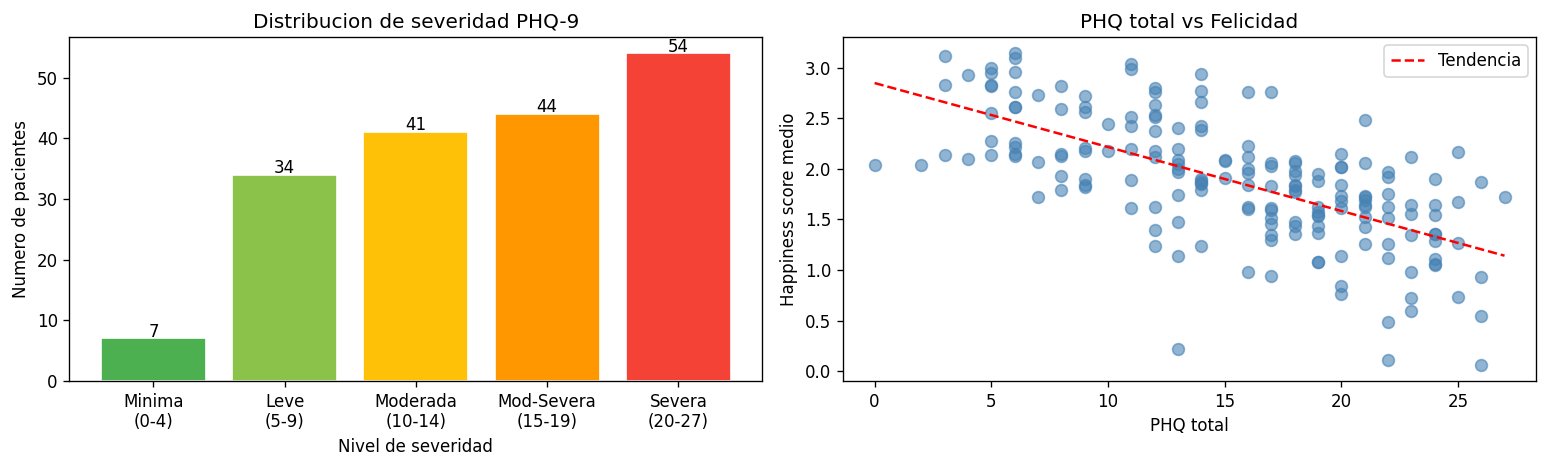

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_phq = pd.read_csv('../data/raw/PHQ-9/Dataset_14-day_AA_depression_symptoms_mood_and_PHQ-9.csv')
phq_items = [f'phq{i}' for i in range(1, 10)]
df_phq['phq_total'] = df_phq[phq_items].sum(axis=1, min_count=1)
df_phq = df_phq.dropna(subset=['phq_total'])

df_user = df_phq.groupby('user_id').agg(
    phq_total=('phq_total', 'first'),
    happiness=('happiness.score', 'mean'),
    n_obs=('phq_total', 'count')
).reset_index()

print(f'Filas totales   : {len(df_phq):,}')
print(f'Pacientes       : {df_phq["user_id"].nunique()}')
obs = df_phq.groupby('user_id').size()
print(f'Obs/paciente    : min={obs.min()} max={obs.max()} media={obs.mean():.0f}')
print(f'PHQ media       : {df_user["phq_total"].mean():.1f} +/- {df_user["phq_total"].std():.1f}')

bins = [0, 4, 9, 14, 19, 27]
etiq = ['Minima\n(0-4)', 'Leve\n(5-9)', 'Moderada\n(10-14)', 'Mod-Severa\n(15-19)', 'Severa\n(20-27)']
df_user['severidad'] = pd.cut(df_user['phq_total'], bins=bins, labels=etiq, include_lowest=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

conteos = df_user['severidad'].value_counts().reindex(etiq)
colores = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']
ax1.bar(etiq, conteos.values, color=colores, edgecolor='white')
ax1.set_xlabel('Nivel de severidad')
ax1.set_ylabel('Numero de pacientes')
ax1.set_title('Distribucion de severidad PHQ-9')
for i, v in enumerate(conteos.values):
    ax1.text(i, v + 0.3, str(v), ha='center', fontsize=10)

z = np.polyfit(df_user['phq_total'].dropna(), df_user['happiness'].dropna(), 1)
x_line = np.linspace(df_user['phq_total'].min(), df_user['phq_total'].max(), 100)
ax2.scatter(df_user['phq_total'], df_user['happiness'], alpha=0.6, color='steelblue', s=50)
ax2.plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=1.5, label='Tendencia')
ax2.set_xlabel('PHQ total')
ax2.set_ylabel('Happiness score medio')
ax2.set_title('PHQ total vs Felicidad')
ax2.legend()
plt.tight_layout()
plt.show()

## 8. Limitaciones del proyecto <a id='8'></a>

Es importante ser honesto sobre las limitaciones para contextualizar correctamente los resultados:

**Dataset pequeño para deep learning**  
Con ~1,600 sujetos de entrenamiento, los modelos clásicos (SVM, XGB) frecuentemente superan a redes neuronales. Los papers que reportan ventajas de deep learning en neuroimagen típicamente usan 5,000+ sujetos o transfer learning desde modelos pre-entrenados.

**Especificidad baja en todos los modelos**  
El mejor modelo (SVM combined_combat, AUC=0.739) tiene sensibilidad=0.815 pero especificidad=0.512 clasifica bien a los enfermos pero genera muchos falsos positivos en sanos. En un contexto clínico real esto requeriría un umbral de decisión más conservador.

**Generalización inter-poblacional**  
El dataset es 100% chino. Los modelos entrenados podrían no generalizar a otras etnias o sistemas de salud con diferentes protocolos clínicos.

**Acceso a datos crudos**  
El MLP recibe features ya comprimidas por PCA, no la matriz FC original. En papers de referencia, las redes reciben la matriz completa (1,833×1,833) procesada en GPUs de alta capacidad computacionalmente inviable para este proyecto escolar.

**Heterogeneidad multi-sitio residual**  
ComBat corrige el efecto de sitio pero no lo elimina completamente pueden quedar variaciones residuales que el modelo confunda con señal biológica.